<div class="alert alert-block alert-success">


# **03 — feature engineering pipeline**

## **Goal of this notebook**
The raw columns in the database (goals, minutes_played, date_of_birth, net_transfer_record) are not directly comparable or analytically useful on their own. This notebook derives meaningful metrics from the raw data so that every subsequent notebook has better inputs to work with. This is not analysis — it is preparation for analysis.

### **Some metrics to make**
Player-level metrics
- age — calculated from date_of_birth to a reference date (e.g. latest game date in dataset)
- contract_years_remaining — from contract_expiration_date to reference date
- goals_per_90 — goals / (minutes_played / 90), for players with sufficient appearances
- assists_per_90 — same approach
- goal_contributions_per_90 — (goals + assists) / (minutes_played / 90)
- minutes_played_ratio — minutes_played / (appearances × 90), a proxy for how often a player plays the full match vs gets substituted
- cards_per_90 — (yellow_cards + red_cards×2) / (minutes_played / 90)

Club-level metrics (aggregated from games and appearances)
- win_rate — wins / total_games
- goals_scored_per_game — total goals scored / total games
- goals_conceded_per_game — total goals conceded / total games
- goal_difference_per_game
- avg_attendance — average attendance across home games
- transfer_balance — using the cleaned numeric_net_transfer_record from notebook 02

Game-level metrics
- total_goals — home_club_goals + away_club_goals
- goal_difference — absolute difference between home and away goals
- is_draw, home_win, away_win — boolean outcome flags

##### **the changes are going to take place directly on the database not the raw data**

In [ ]:
# importing the necessaries
import sys
import os
# Adding the root to the path to use utils folder
sys.path.append(os.path.abspath(os.path.join('..')))

from utils.db_utils import run_query , execute_ddl
from utils.custom_plots import distribution_plot, outlier_plot
from utils.schema_diagram import schema_diagram


import plotly.io as pio
pio.renderers.default = "png"  # drop these 2 lines if you want interactive charts locally

<div class="alert alert-block alert-success">

# First lets see the connections 
## here we can have a better understanding of cross-table metrics

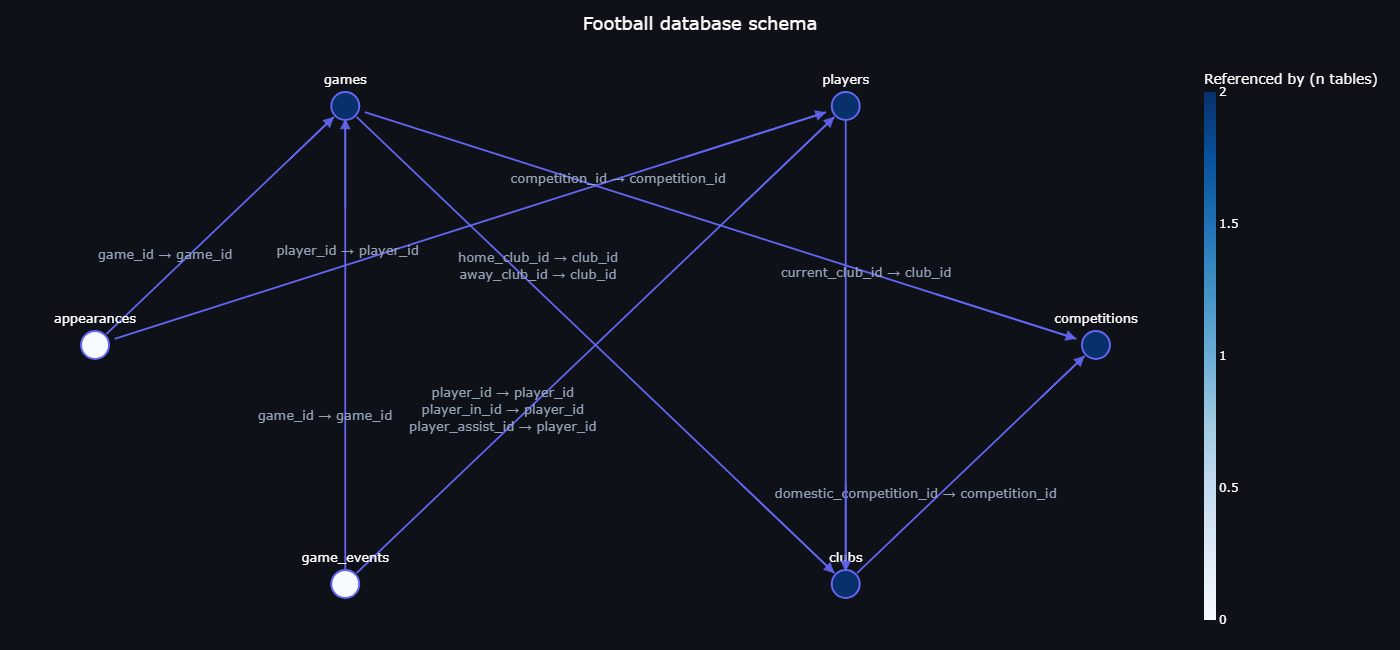

In [ ]:
database_diagram=schema_diagram(run_query_fn=run_query,
                                layout='circular',
                                edge_labels='always',
                                title='Football database schema',
                                edge_label_font_size=13
                                )

database_diagram

<div class="alert alert-block alert-success">

# Player-level metrics:
## 3 tables are involved in this metrics:
- players
- appearances 
- games

In [15]:
# players table columns 
player_df = run_query('select * from players')
player_df.head(5)

,player_id,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,date_of_birth,sub_position,position,foot,height_in_cm,contract_expiration_date
0,569140,290,lassine-sinayoko,NaN,Bamako,NaN,1999-12-08,Right Winger,Attack,right,186.0,2025-06-30
1,569368,44,kelian-nsona,NaN,Ivry-sur-Seine,NaN,2002-05-11,Right Winger,Attack,right,189.0,2026-06-30
2,569385,1158,adil-aouchiche,NaN,Le Blanc-Mesnil,NaN,2002-07-15,Attacking Midfield,Midfield,right,181.0,2026-06-30
3,607809,11127,ilya-bykovskiy,NaN,"Lyubertsy, Moskau Oblast",NaN,2001-02-16,Left-Back,Defender,left,177.0,2024-06-30
4,627221,720,gabriel-veron,NaN,Assu,NaN,2002-09-03,Right Winger,Attack,right,176.0,2027-06-30


In [16]:
# appearances table columns
appearances_df = run_query('select * from appearances')
appearances_df.head(5)

,appearance_id,game_id,player_id,yellow_cards,red_cards,goals,assists,minutes_played
0,3393960_546880,3393960,546880,0,0,0,0,48
1,3393960_57370,3393960,57370,0,0,1,0,90
2,3393960_640428,3393960,640428,0,0,0,1,26
3,3393960_73734,3393960,73734,0,0,0,0,90
4,3393960_84301,3393960,84301,0,0,0,0,90


In [17]:
#games table columns 
df = run_query('select * from games')
df.sort_values('date', ascending=False).head(5)

,game_id,competition_id,season,date,home_club_id,away_club_id,home_club_goals,away_club_goals,stadium,attendance
6767,4112915,ES1,2023,2024-05-16,3302,131,0,2,Power Horse Stadium,15543.0
3723,4112917,ES1,2023,2024-05-16,681,1049,1,0,Reale Arena,25067.0
10530,4112920,ES1,2023,2024-05-16,472,150,2,2,Estadio de Gran Canaria,NaN
14726,4095416,GB1,2023,2024-05-15,985,762,3,2,Old Trafford,NaN
7513,4112923,ES1,2023,2024-05-15,367,16795,2,1,Campo de Fútbol de Vallecas,12738.0


<div class="alert alert-block alert-success">

### now we will implement the player-level metrics 

In [18]:
# creating age metric: